In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets
from tensorflow.keras import layers

In [22]:
from keras.datasets import cifar100

In [23]:
df=datasets.cifar100.load_data()

In [24]:
print(df)

((array([[[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [195, 205, 193],
         [212, 224, 204],
         [182, 194, 167]],

        [[255, 255, 255],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [170, 176, 150],
         [161, 168, 130],
         [146, 154, 113]],

        [[255, 255, 255],
         [254, 254, 254],
         [255, 255, 255],
         ...,
         [189, 199, 169],
         [166, 178, 130],
         [121, 133,  87]],

        ...,

        [[148, 185,  79],
         [142, 182,  57],
         [140, 179,  60],
         ...,
         [ 30,  17,   1],
         [ 65,  62,  15],
         [ 76,  77,  20]],

        [[122, 157,  66],
         [120, 155,  58],
         [126, 160,  71],
         ...,
         [ 22,  16,   3],
         [ 97, 112,  56],
         [141, 161,  87]],

        [[ 87, 122,  41],
         [ 88, 122,  39],
         [101, 134,  56],
         ...,
         [ 34,  36,  10],
      

In [25]:
(x_train,y_train),(x_test,y_test)=df

In [26]:
x_train = x_train/255.0
x_test = x_test/255.0

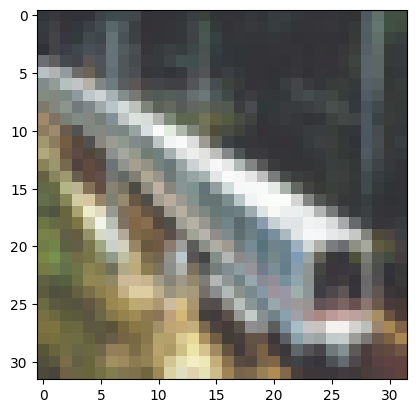

In [27]:
import matplotlib.pyplot as plt
plt.imshow(x_train[6])

In [28]:
y_train[6]

array([90])

In [29]:
classes = [
'apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle','bicycle','bottle',
'bowl','boy','bridge','bus','butterfly','camel','can','castle','caterpillar','cattle',
'chair','chimpanzee','clock','cloud','cockroach','couch','crab','crocodile','cup','dinosaur',
'dolphin','elephant','flatfish','forest','fox','girl','hamster','house','kangaroo','keyboard',
'lamp','lawn_mower','leopard','lion','lizard','lobster','man','maple_tree','motorcycle','mountain',
'mouse','mushroom','oak_tree','orange','orchid','otter','palm_tree','pear','pickup_truck','pine_tree',
'plain','plate','poppy','porcupine','possum','rabbit','raccoon','ray','road','rocket',
'rose','sea','seal','shark','shrew','skunk','skyscraper','snail','snake','spider',
'squirrel','streetcar','sunflower','sweet_pepper','table','tank','telephone','television','tiger','tractor',
'train','trout','tulip','turtle','wardrobe','whale','willow_tree','wolf','woman','worm'
]

In [30]:
print(classes[y_train[6][0]])

train


In [31]:
x_train.shape

(50000, 32, 32, 3)

In [32]:
model=keras.Sequential([
    layers.Conv2D(64,(3,3),activation="relu",input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    keras.layers.Dense(50,activation="relu"),
    keras.layers.Dense(100,activation="softmax"),
])

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.compile(metrics=["accuracy"],loss="sparse_categorical_crossentropy",optimizer="Adam")

In [34]:
model.fit(x_train,y_train,epochs=20)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.0943 - loss: 3.9724
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1864 - loss: 3.4000
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2302 - loss: 3.1561
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2614 - loss: 2.9899
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2829 - loss: 2.8743
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3001 - loss: 2.7907
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3093 - loss: 2.7313
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3213 - loss: 2.6798
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3304 - loss: 2.6354
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3358 - loss: 2.5976
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3433 - loss: 2.5624
Epoch 12/20
1563/1563 ━━━━━━━

In [35]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3367 - loss: 2.6320


[2.63199520111084, 0.3366999924182892]

In [36]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [37]:
y_pred[786]

array([5.96514980e-08, 5.37472658e-07, 1.16727438e-06, 6.14572997e-08,
       1.47215957e-07, 1.47895435e-06, 6.31817432e-10, 1.18949811e-06,
       7.83716148e-10, 4.44106441e-08, 4.32214066e-02, 2.62869798e-06,
       2.17794266e-07, 1.23017991e-03, 9.30355384e-07, 3.93577926e-09,
       1.05798266e-04, 1.51890625e-10, 4.04797227e-08, 6.16399098e-10,
       8.80903683e-10, 6.01756583e-05, 8.67424190e-01, 3.39260060e-13,
       1.68003278e-09, 1.12055832e-05, 9.95816299e-05, 6.43786624e-09,
       8.18822912e-07, 1.06583464e-09, 6.18962970e-09, 2.34582354e-11,
       2.09055579e-05, 1.46408241e-09, 7.52940696e-11, 3.40486508e-06,
       3.78977319e-07, 4.52624903e-07, 1.35623760e-11, 2.79661268e-04,
       1.66203419e-03, 1.10452682e-07, 4.24325641e-09, 1.08833174e-08,
       8.06356582e-09, 2.61653128e-07, 1.53187364e-06, 8.90450094e-13,
       1.13679710e-06, 1.33479686e-10, 5.77849096e-06, 4.65591114e-07,
       2.93178307e-12, 4.86918450e-10, 2.73075162e-09, 1.70212545e-07,
      

In [38]:
prob=y_pred[786].argmax()
prob

np.int64(22)

In [39]:
y_test[786].argmax()

np.int64(0)

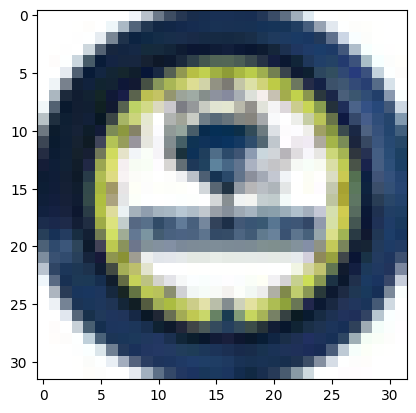

In [40]:
plt.imshow(x_test[786])

In [43]:
print(classes[y_test[786][0]])

clock
